In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/scoring"
    !pip install -q interpret shap fairlearn lightgbm xgboost
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, PROJECT_ROOT)
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")

# Download dataset if not present
os.makedirs(DATA_DIR, exist_ok=True)
if not any(f.endswith((".gzip", ".gz", ".csv")) for f in os.listdir(DATA_DIR) if not f.startswith(".")):
    print("Downloading Lending Club dataset...")
    !curl -L -o /tmp/lending-club.zip https://www.kaggle.com/api/v1/datasets/download/ethon0426/lending-club-20072020q1
    !unzip -o /tmp/lending-club.zip -d {DATA_DIR}/
    !rm /tmp/lending-club.zip
    print("Dataset downloaded.")
else:
    print("Dataset already present.")

Dataset already present.


# Phase 1: Data Acquisition & EDA

## 1.1 Load raw data

In [2]:
from src.data import load_raw, define_target, temporal_split
from src.features import average_fico, encode_categoricals, COLUMN_TYPES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)

df_raw = load_raw(DATA_DIR)
print(f"Raw dataset: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
df_raw.head()

Raw dataset: 2,925,493 rows, 142 columns


,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,dti,delinq_2yrs,...,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
0,0,1077501,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-2011,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,credit_card,Computer,860xx,AZ,27.65,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
1,1,1077430,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-2011,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,car,bike,309xx,GA,1.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
2,2,1077175,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-2011,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,small_business,real estate business,606xx,IL,8.72,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
3,3,1076863,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-2011,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,other,personel,917xx,CA,20.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
4,4,1075358,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-2011,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,other,Personal,972xx,OR,17.94,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N


In [3]:
# Missing values overview
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("pct", ascending=False)
print(f"Columns with missing values: {len(missing_df)} / {df_raw.shape[1]}")
missing_df.head(20)

Columns with missing values: 140 / 142


,count,pct
deferral_term,2781855,95.1
hardship_length,2781855,95.1
hardship_type,2781855,95.1
hardship_reason,2781861,95.1
hardship_status,2781858,95.1
hardship_start_date,2781855,95.1
hardship_end_date,2781855,95.1
payment_plan_start_date,2781855,95.1
hardship_dpd,2781856,95.1
hardship_loan_status,2782082,95.1


In [4]:
# Data types overview
print("Data types:")
print(df_raw.dtypes.value_counts())
print(f"\nloan_status distribution:")
print(df_raw["loan_status"].value_counts())

Data types:
float64    106
object      35
int64        1
Name: count, dtype: int64

loan_status distribution:
loan_status
Fully Paid                                             1497783
Current                                                1031016
Charged Off                                             362548
Late (31-120 days)                                       16154
In Grace Period                                          10028
Late (16-30 days)                                         2719
Issued                                                    2062
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                    433
Name: count, dtype: int64


## 1.2 Define target (Fully Paid vs Charged Off)

In [5]:
# Keep only Fully Paid and Charged Off
df = define_target(df_raw)
print(f"After filtering: {df.shape[0]:,} rows ({df.shape[0]/df_raw.shape[0]*100:.1f}% of original)")
print(f"\nTarget distribution:")
print(df["target"].value_counts())
print(f"\nDefault rate: {df['target'].mean()*100:.1f}%")

# Drop columns not useful for modeling
drop_cols = [
    "Unnamed: 0", "id", "url", "title", "emp_title",  # identifiers / free text
    "loan_status",  # already encoded as target
    "pymnt_plan", "policy_code",  # near-constant
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",  # post-loan info (leakage)
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",  # post-loan info (leakage)
    "recoveries", "collection_recovery_fee",  # post-loan info (leakage)
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",  # post-loan info
    "last_fico_range_high", "last_fico_range_low",  # post-loan FICO
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",  # post-loan hardship
    "deferral_term", "hardship_amount", "hardship_start_date", "hardship_end_date",
    "payment_plan_start_date", "hardship_length", "hardship_dpd", "hardship_loan_status",
    "orig_projected_additional_accrued_interest", "hardship_payoff_balance_amount",
    "hardship_last_payment_amount", "debt_settlement_flag",
    # Joint application columns (mostly null for individual apps)
    "annual_inc_joint", "dti_joint", "verification_status_joint",
    "revol_bal_joint", "sec_app_fico_range_low", "sec_app_fico_range_high",
    "sec_app_earliest_cr_line", "sec_app_inq_last_6mths", "sec_app_mort_acc",
    "sec_app_open_acc", "sec_app_revol_util", "sec_app_open_act_il",
    "sec_app_num_rev_accts", "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med",
]
existing_drop = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=existing_drop)
print(f"\nAfter dropping leakage/identifier columns: {df.shape[1]} columns remaining")

After filtering: 1,860,331 rows (63.6% of original)

Target distribution:
target
0    1497783
1     362548
Name: count, dtype: int64

Default rate: 19.5%



After dropping leakage/identifier columns: 89 columns remaining


## 1.3 Feature engineering (FICO averaging, encoding, imputation)

In [6]:
# 1.3a FICO averaging
df = average_fico(df)
print(f"Created 'fico' column (mean of fico_range_high and fico_range_low)")
print(f"FICO stats:\n{df['fico'].describe()}")

# Clean int_rate (remove % sign if string)
if df["int_rate"].dtype == object:
    df["int_rate"] = df["int_rate"].str.replace("%", "").astype(float)

# Clean term (extract number)
if df["term"].dtype == object:
    df["term"] = df["term"].str.extract(r"(\d+)").astype(float)

# Clean earliest_cr_line to months since
if "earliest_cr_line" in df.columns:
    df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
    reference = pd.to_datetime("Jul-2015", format="%b-%Y")
    df["cr_hist_months"] = ((reference - df["earliest_cr_line"]).dt.days / 30.44).round()
    df = df.drop(columns=["earliest_cr_line"])

print(f"\nColumns before encoding: {df.shape[1]}")

Created 'fico' column (mean of fico_range_high and fico_range_low)
FICO stats:
count    1.860331e+06
mean     6.996786e+02
std      3.270902e+01
min      6.270000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.170000e+02
max      8.475000e+02
Name: fico, dtype: float64



Columns before encoding: 88


In [7]:
# 1.3b Normalize categorical strings (lowercase + strip) on known categorical columns only.
# NO one-hot encoding here — the Pipeline's ColumnTransformer handles OHE per fold.
# NO imputation here — the Pipeline's ColumnTransformer handles it per fold.
from src.features import COLUMN_TYPES

df = encode_categoricals(df, columns=COLUMN_TYPES["categorical"])
print(f"After string normalization: {df.shape[1]} columns (unchanged shape)")
print("Sample purpose values:", df['purpose'].dropna().unique()[:5].tolist() if 'purpose' in df.columns else "N/A")


After string normalization: 88 columns (unchanged shape)
Sample purpose values: ['credit_card', 'car', 'small_business', 'other', 'wedding']


## 1.4 Temporal train/test split

In [8]:
# Temporal split: train through Jul-2015, test Aug-2015 to Dec-2018
train, test = temporal_split(df, date_col="issue_d", train_end="Jul-2015", test_end="Dec-2018")

# Keep issue_d so downstream CV can carve time-series splits.
# Separate features and target.
X_train = train.drop(columns=["target"])
y_train = train["target"]
X_test  = test.drop(columns=["target"])
y_test  = test["target"]

print(f"Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"\nTrain default rate: {y_train.mean()*100:.1f}%")
print(f"Test default rate:  {y_test.mean()*100:.1f}%")
print(f"\nFeature count: {X_train.shape[1]}")
print(f"issue_d present: {'issue_d' in X_train.columns}")


Train: 684,592 rows, 87 features
Test:  1,096,128 rows, 87 features

Train default rate: 17.6%
Test default rate:  20.9%

Feature count: 87
issue_d present: True


## 1.5 EDA: class imbalance, feature distributions, correlation heatmap

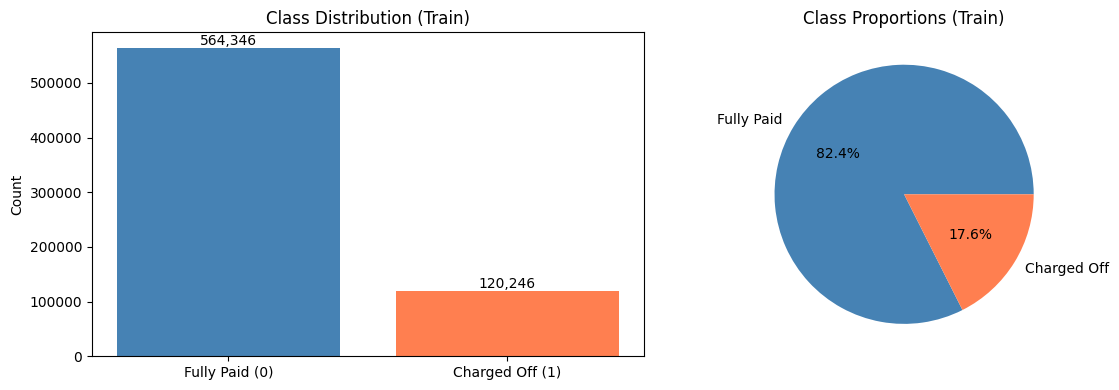

Default rate: 17.6%


In [9]:
# 1.5a Class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = y_train.value_counts()
axes[0].bar(["Fully Paid (0)", "Charged Off (1)"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("Class Distribution (Train)")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha="center")

# Pie chart
axes[1].pie(counts.values, labels=["Fully Paid", "Charged Off"],
            autopct="%1.1f%%", colors=["steelblue", "coral"])
axes[1].set_title("Class Proportions (Train)")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Default rate: {y_train.mean()*100:.1f}%")

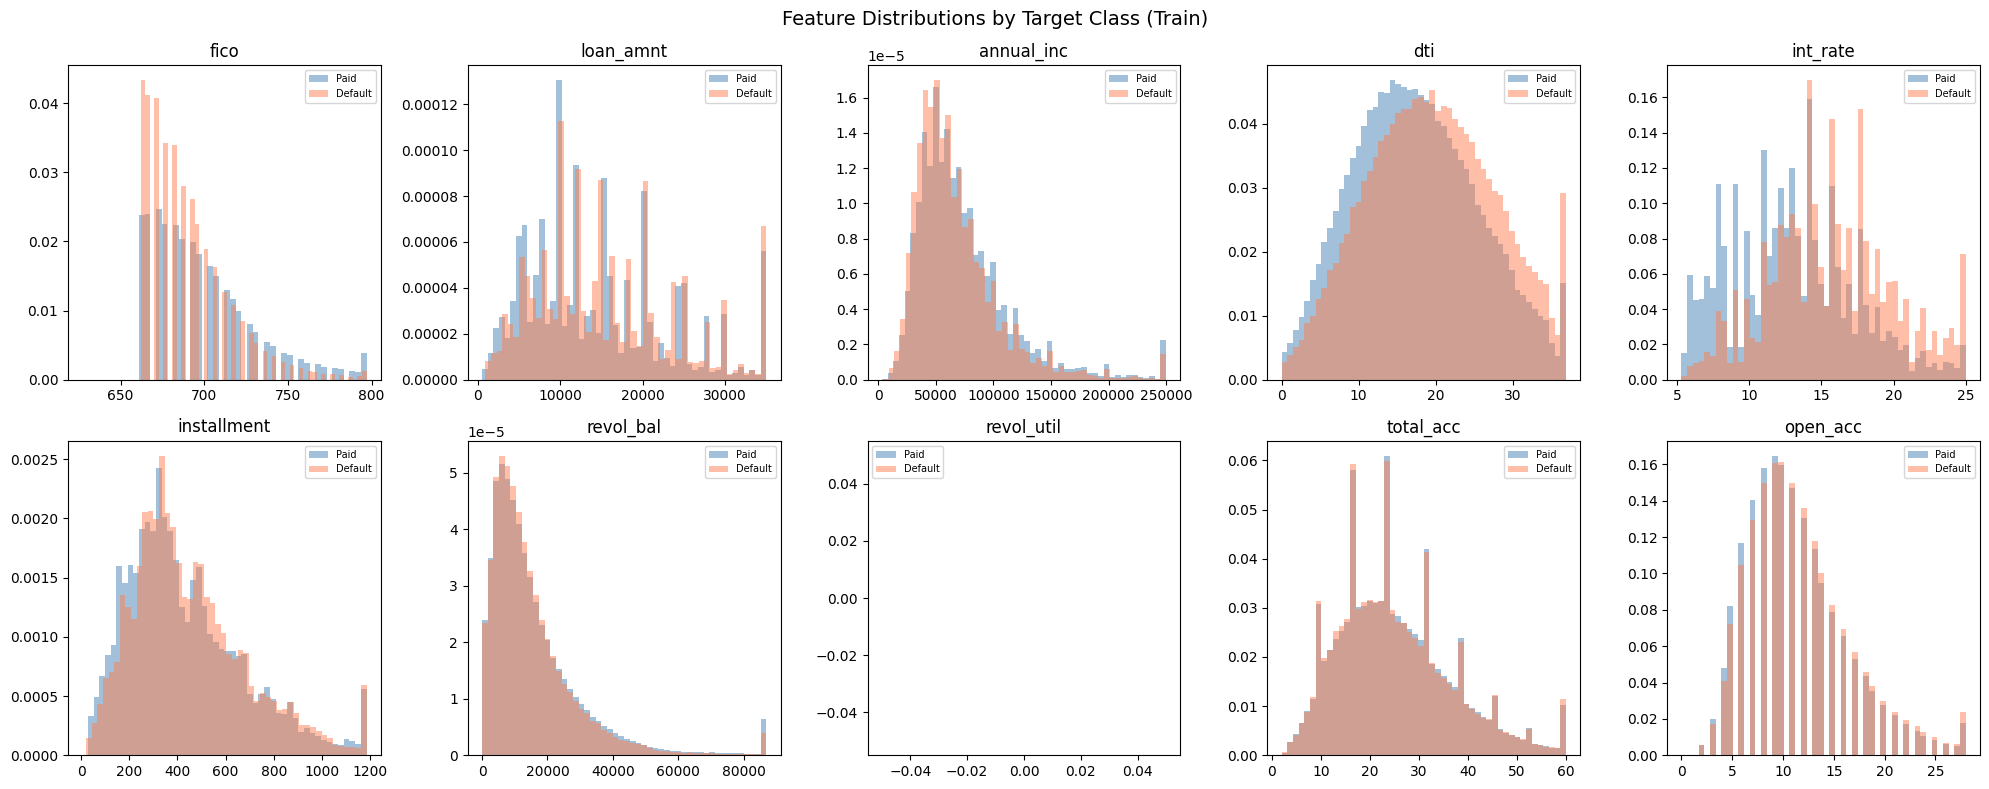

In [10]:
# 1.5b Key feature distributions (numeric, pre-encoding originals)
# Use train set to show distributions of important numeric features.
# Since we now keep raw dtypes (no impute_missing pre-casting), force numeric.
key_features = ["fico", "loan_amnt", "annual_inc", "dti", "int_rate", "installment",
                "revol_bal", "revol_util", "total_acc", "open_acc"]
available = [f for f in key_features if f in X_train.columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(available):
    ax = axes[i // 5, i % 5]
    # Coerce to numeric (some cols may be object dtype in raw data)
    series = pd.to_numeric(X_train[col], errors="coerce")
    q99 = series.quantile(0.99)
    data = series.clip(upper=q99)
    ax.hist(data[y_train == 0].dropna(), bins=50, alpha=0.5, label="Paid", color="steelblue", density=True)
    ax.hist(data[y_train == 1].dropna(), bins=50, alpha=0.5, label="Default", color="coral", density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)

plt.suptitle("Feature Distributions by Target Class (Train)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()


Top 15 features correlated with target (absolute):
int_rate                0.231843
fico                    0.118736
acc_open_past_24mths    0.105474
dti                     0.095243
num_tl_op_past_12m      0.092424
bc_open_to_buy          0.073745
avg_cur_bal             0.070821
total_bc_limit          0.070352
tot_hi_cred_lim         0.069397
tot_cur_bal             0.062980
mo_sin_rcnt_tl          0.061925
percent_bc_gt_75        0.061755
num_rev_tl_bal_gt_0     0.061389
num_actv_rev_tl         0.061334
inq_last_6mths          0.060809


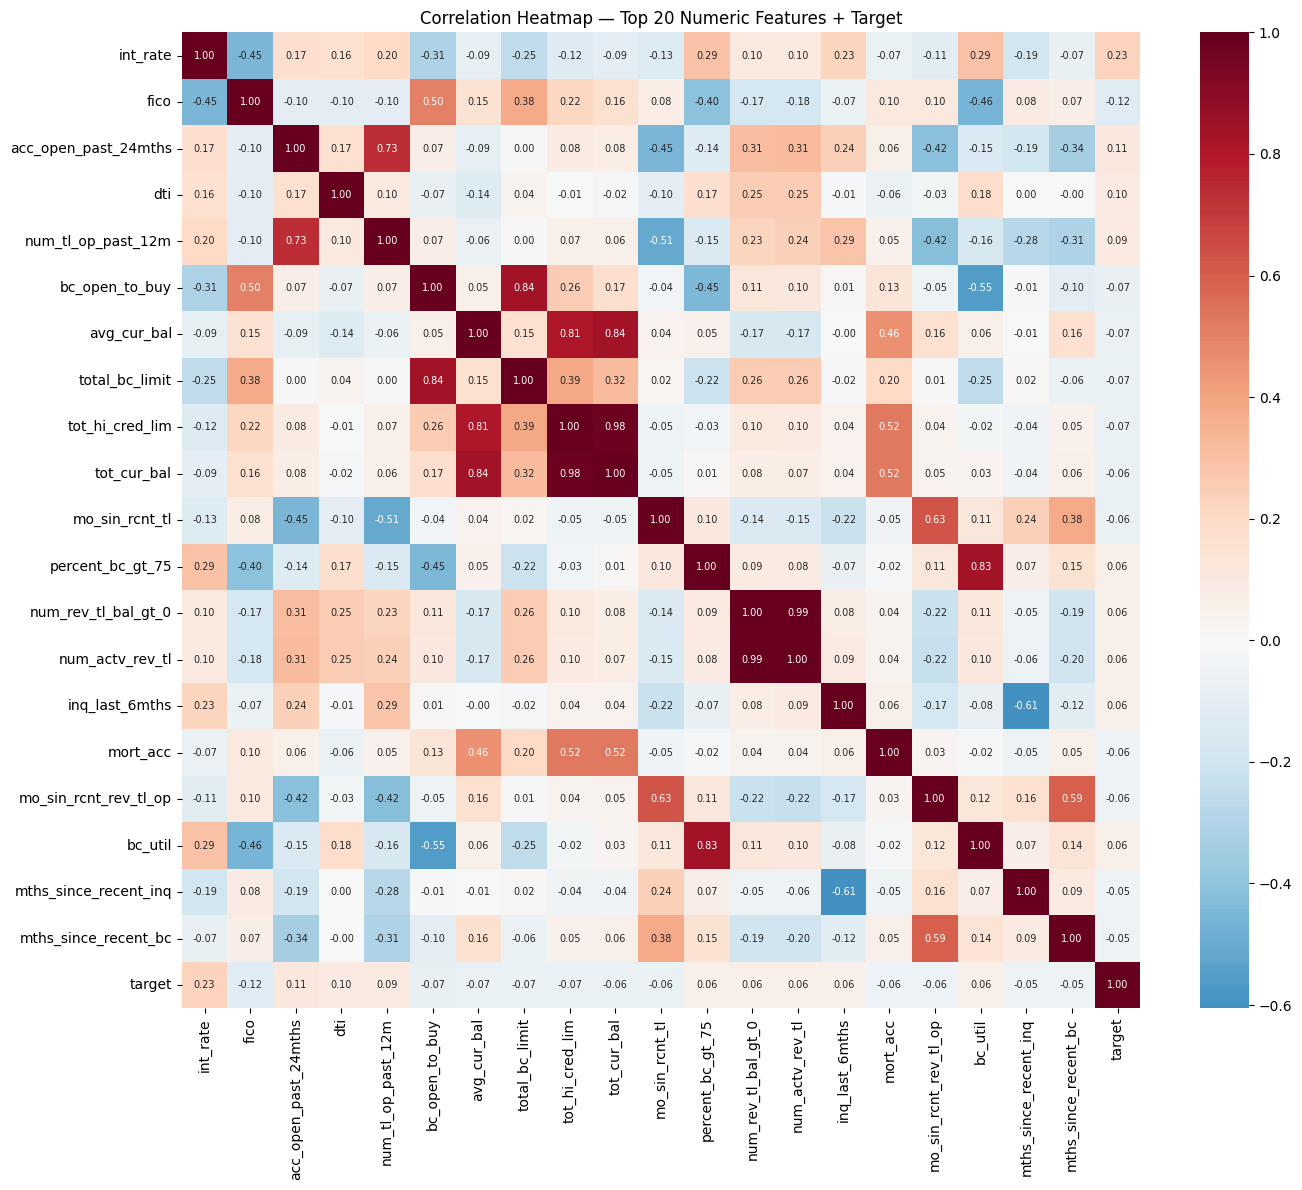

In [11]:
# 1.5c Correlation heatmap (numeric features only)
# Since X_train now contains raw string-valued categorical columns,
# select only numeric-dtype columns for the correlation analysis.
numeric_cols = X_train.select_dtypes(include="number").columns.tolist()

# Add target for correlation
corr_data = X_train[numeric_cols].assign(target=y_train.values)
corr = corr_data.corr()

# Show top correlations with target
target_corr = corr["target"].drop("target").abs().sort_values(ascending=False)
print("Top 15 features correlated with target (absolute):")
print(target_corr.head(15).to_string())

# Heatmap of top 20 correlated features
top_features = target_corr.head(20).index.tolist() + ["target"]
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_data[top_features].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Heatmap — Top 20 Numeric Features + Target")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()


## 1.6 Save processed data for Phase 2

In [12]:
# Align X_train and X_test columns with COLUMN_TYPES manifest so the
# ColumnTransformer in downstream notebooks has every expected column.
# Missing columns added as NaN (numeric imputer handles them).
from src.features import COLUMN_TYPES

expected = set(COLUMN_TYPES["numeric"]) | set(COLUMN_TYPES["count"]) | set(COLUMN_TYPES["categorical"])
# preserve issue_d so CV can carve splits downstream
keep_extra = {"issue_d"} & (set(X_train.columns) | set(X_test.columns))

for df_name, df in [("X_train", X_train), ("X_test", X_test)]:
    for col in expected:
        if col not in df.columns:
            df[col] = float("nan")
    # drop any column not in expected and not explicitly kept
    extra_to_drop = [c for c in df.columns if c not in expected and c not in keep_extra]
    df.drop(columns=extra_to_drop, inplace=True)

# Ensure consistent column order across train and test
final_cols = sorted(expected) + sorted(keep_extra)
X_train = X_train[final_cols]
X_test  = X_test[final_cols]

print("X_train columns:", len(X_train.columns), "X_test columns:", len(X_test.columns))
print("X_train rows:", len(X_train), "X_test rows:", len(X_test))


X_train columns: 61 X_test columns: 61
X_train rows: 684592 X_test rows: 1096128


In [13]:
from pathlib import Path
import json
from src.features import COLUMN_TYPES

PROCESSED = Path(PROJECT_ROOT) / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

# Raw-but-cleaned: target defined, Jul-2015 split, FICO averaged,
# categorical strings normalized.  NO imputation, NO one-hot.
# Columns aligned to COLUMN_TYPES for downstream Pipelines.
X_train.to_csv(PROCESSED / "X_train_raw.csv", index=False)
X_test.to_csv(PROCESSED  / "X_test_raw.csv",  index=False)
y_train.to_csv(PROCESSED / "y_train.csv", index=False)
y_test.to_csv(PROCESSED  / "y_test.csv",  index=False)

REPORTS = Path(PROJECT_ROOT) / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)
with (REPORTS / "column_types.json").open("w") as f:
    json.dump(COLUMN_TYPES, f, indent=2)

print("Saved:", PROCESSED / "X_train_raw.csv", "rows =", len(X_train))
print("Saved:", PROCESSED / "X_test_raw.csv",  "rows =", len(X_test))
print("Saved:", REPORTS   / "column_types.json")


Saved: /Users/abdro/ML/scoring/data/processed/X_train_raw.csv rows = 684592
Saved: /Users/abdro/ML/scoring/data/processed/X_test_raw.csv rows = 1096128
Saved: /Users/abdro/ML/scoring/reports/column_types.json


Saved: reports/cv_folds_timeline.png


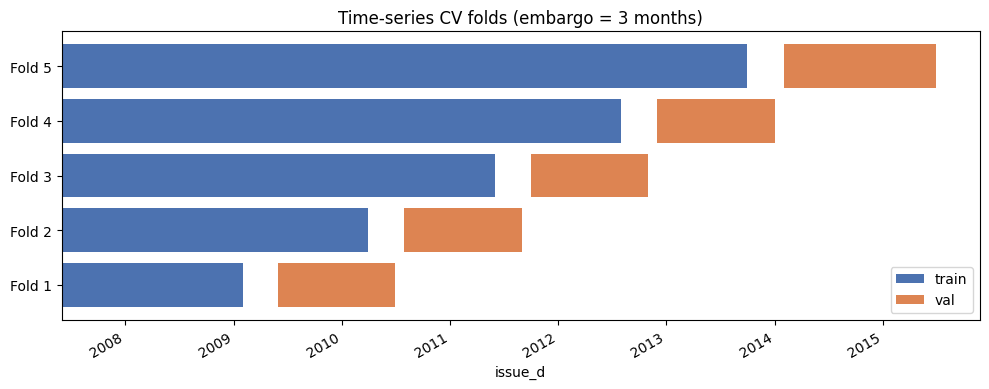

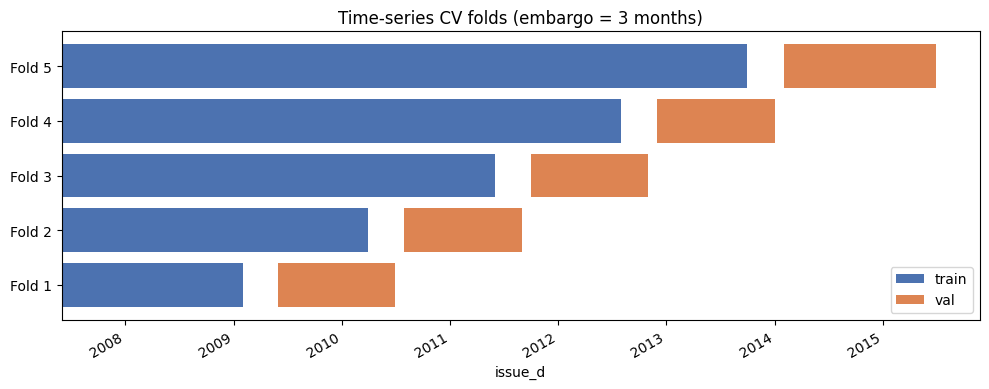

In [14]:
from pathlib import Path
import pandas as pd
from src.validation import make_time_series_splits, plot_fold_timeline
from src.config import CONFIG

train_dates = pd.to_datetime(X_train[CONFIG.date_col])
splits = make_time_series_splits(
    train_dates,
    n_splits=CONFIG.n_splits_outer,
    embargo_months=CONFIG.embargo_months,
    min_train_months=CONFIG.min_train_months,
)
fig, ax = plot_fold_timeline(
    train_dates, splits, CONFIG.embargo_months,
    out_path=Path(PROJECT_ROOT) / "reports" / "cv_folds_timeline.png"
)
print("Saved: reports/cv_folds_timeline.png")
fig
